HEART DISEASE PREDICTION


importing the dependencies

In [ ]:

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix,classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.svm import SVC


data collection and processing

In [ ]:
df=pd.read_csv('/content/Cardiovascular_Disease_Dataset.csv')
print("Columns in DataFrame after loading:", df.columns.tolist())

Columns in DataFrame after loading: ['patientid', 'age', 'gender', 'chestpain', 'restingBP', 'serumcholestrol', 'fastingbloodsugar', 'restingrelectro', 'maxheartrate', 'exerciseangia', 'oldpeak', 'slope', 'noofmajorvessels', 'target']


In [ ]:

#deleting the patiendid colunm
df = df.drop('patientid', axis=1)

# Save the updated DataFrame back to CSV
df.to_csv('data.csv', index=False)


In [ ]:
#loading the csv to pandas dataframe
heart_data=pd.read_csv('data.csv')

heart_data= df.rename(columns={
    'age': 'age',
    'gender': 'gender',
    'chestpain': 'CP',
    'restingBP': 'RBP',
    'serumcholestrol': 'SC',
    'fastingbloodsugar': 'FBS',
    'restingrelectro': 'RECG',
    'maxheartrate': 'MHR',
    'exerciseangia': 'exan',
    'oldpeak': 'OP',
    'slope': 'slope',
    'noofmajorvessels': 'NVM',
    'target': 'target'
})


In [ ]:
#print first 5 rows of the dataset
heart_data.head()

,age,gender,CP,RBP,SC,FBS,RECG,MHR,exan,OP,slope,NVM,target
0,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,31,1,1,199,0,0,2,136,0,5.3,3,2,1


In [ ]:
print(heart_data)

     age  gender  CP  RBP   SC  FBS  RECG  MHR  exan   OP  slope  NVM  target
0     53       1   2  171    0    0     1  147     0  5.3      3    3       1
1     40       1   0   94  229    0     1  115     0  3.7      1    1       0
2     49       1   2  133  142    0     0  202     1  5.0      1    0       0
3     43       1   0  138  295    1     1  153     0  3.2      2    2       1
4     31       1   1  199    0    0     2  136     0  5.3      3    2       1
..   ...     ...  ..  ...  ...  ...   ...  ...   ...  ...    ...  ...     ...
995   48       1   2  139  349    0     2  183     1  5.6      2    2       1
996   47       1   3  143  258    1     1   98     1  5.7      1    0       0
997   69       1   0  156  434    1     0  196     0  1.4      3    1       1
998   45       1   1  186  417    0     1  117     1  5.9      3    2       1
999   25       1   0  158  270    0     0  143     1  4.7      0    0       0

[1000 rows x 13 columns]


In [ ]:
!pip install python-docx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 6.2 MB/s eta 0:00:00


In [ ]:
#number of rows and columns in the dataset
heart_data.shape

(1000, 13)

In [ ]:
#getting some info about the data
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     1000 non-null   int64  
 1   gender  1000 non-null   int64  
 2   CP      1000 non-null   int64  
 3   RBP     1000 non-null   int64  
 4   SC      1000 non-null   int64  
 5   FBS     1000 non-null   int64  
 6   RECG    1000 non-null   int64  
 7   MHR     1000 non-null   int64  
 8   exan    1000 non-null   int64  
 9   OP      1000 non-null   float64
 10  slope   1000 non-null   int64  
 11  NVM     1000 non-null   int64  
 12  target  1000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 101.7 KB


In [ ]:
#statistical measure about the data
heart_data.describe()

,age,gender,CP,RBP,SC,FBS,RECG,MHR,exan,OP,slope,NVM,target
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,49.24200,0.765000,0.980000,151.747000,311.447000,0.296000,0.748000,145.477000,0.498000,2.707700,1.540000,1.222000,0.580000
std,17.86473,0.424211,0.953157,29.965228,132.443801,0.456719,0.770123,34.190268,0.500246,1.720753,1.003697,0.977585,0.493805
min,20.00000,0.000000,0.000000,94.000000,0.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.00000,1.000000,0.000000,129.000000,235.750000,0.000000,0.000000,119.750000,0.000000,1.300000,1.000000,0.000000,0.000000
50%,49.00000,1.000000,1.000000,147.000000,318.000000,0.000000,1.000000,146.000000,0.000000,2.400000,2.000000,1.000000,1.000000
75%,64.25000,1.000000,2.000000,181.000000,404.250000,1.000000,1.000000,175.000000,1.000000,4.100000,2.000000,2.000000,1.000000
max,80.00000,1.000000,3.000000,200.000000,602.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000


In [ ]:
from docx import Document
from docx.shared import Inches

# Get the statistical summary
stats_table = heart_data.describe()

# Create a new Word Document
doc = Document()

# Add a title
doc.add_heading('Heart Data Statistical Summary', 0)

# Create a table in Word (rows + 1 for header, cols + 1 for index)
table = doc.add_table(rows=stats_table.shape[0] + 1, cols=stats_table.shape[1] + 1)
table.style = 'Light Grid Accent 1'

# Add column headers
table.cell(0, 0).text = ''  # Top-left cell
for j, col_name in enumerate(stats_table.columns):
    table.cell(0, j + 1).text = str(col_name)

# Add row data
for i, row_name in enumerate(stats_table.index):
    table.cell(i + 1, 0).text = str(row_name)  # Row index names
    for j, value in enumerate(stats_table.iloc[i]):
        table.cell(i + 1, j + 1).text = f'{value:.2f}'

# Save the document
doc.save('heart_data_statistics.docx')
print("Word document created successfully: heart_data_statistics.docx")

Word document created successfully: heart_data_statistics.docx


Correlation matrix heatmap

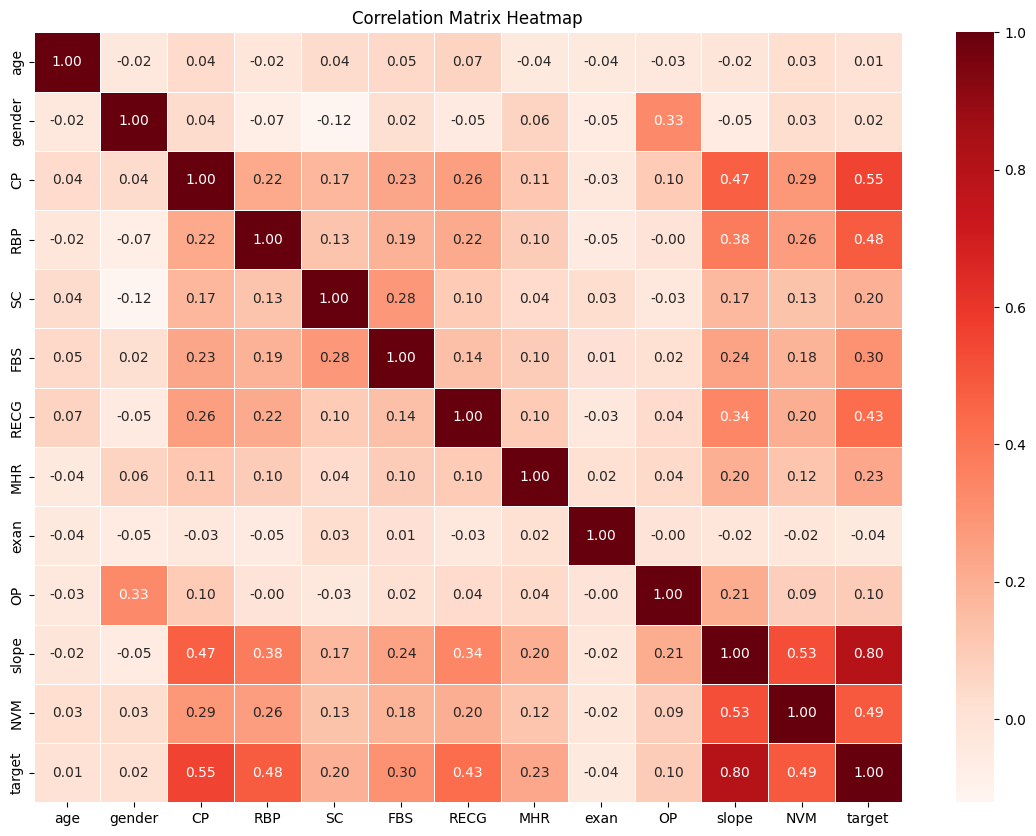

In [ ]:
# Calculate correlation matrix
corr =heart_data.corr()

# Set plot size
plt.figure(figsize=(14, 10))

# Plot heatmap
sns.heatmap(corr,
            annot=True,        # show values in cells
            cmap='Reds',       # similar red color theme
            linewidths=0.5,    # grid lines
            fmt=".2f")         # number format

plt.title("Correlation Matrix Heatmap")
plt.show()

In [ ]:
#checking the disttribution of target variable
heart_data['target'].value_counts()

,count
target,
1,580
0,420


1-->defective heart

0-->healthy heart

splitting the features and target

In [ ]:
x=heart_data.drop(columns='target',axis=1)
y=heart_data['target']

In [ ]:
print(x)

     age  gender  CP  RBP   SC  FBS  RECG  MHR  exan   OP  slope  NVM
0     53       1   2  171    0    0     1  147     0  5.3      3    3
1     40       1   0   94  229    0     1  115     0  3.7      1    1
2     49       1   2  133  142    0     0  202     1  5.0      1    0
3     43       1   0  138  295    1     1  153     0  3.2      2    2
4     31       1   1  199    0    0     2  136     0  5.3      3    2
..   ...     ...  ..  ...  ...  ...   ...  ...   ...  ...    ...  ...
995   48       1   2  139  349    0     2  183     1  5.6      2    2
996   47       1   3  143  258    1     1   98     1  5.7      1    0
997   69       1   0  156  434    1     0  196     0  1.4      3    1
998   45       1   1  186  417    0     1  117     1  5.9      3    2
999   25       1   0  158  270    0     0  143     1  4.7      0    0

[1000 rows x 12 columns]


In [ ]:
print(y)

0      1
1      0
2      0
3      1
4      1
      ..
995    1
996    0
997    1
998    1
999    0
Name: target, Length: 1000, dtype: int64


splitting the data into training data and test data

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=2)


In [ ]:
print(x.shape,x_train.shape,x_test.shape)

(1000, 12) (800, 12) (200, 12)


Logistic Regression

model traning

In [ ]:
model1 = LogisticRegression(max_iter=200)

#training the logistic regression model with training data
model1.fit(x_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=200)

model evaluation

accuracy score

In [ ]:
#accuracy on training data
x_train_prediction=model1.predict(x_train)
training_data_accuracy=accuracy_score(x_train_prediction,y_train)


In [ ]:
print('accuracy on training data:',training_data_accuracy)

accuracy on training data: 0.95


In [ ]:
#accuracy on test data
x_test_prediction=model1.predict(x_test)
test_data_accuracy=accuracy_score(x_test_prediction,y_test)


In [ ]:
print('accuracy on test data:',test_data_accuracy)

accuracy on test data: 0.965


building a predictive system


In [ ]:
input_data=(49,1,2,133,142,0,0,202,1,5,1,0)

#change the input data to a numpy array
input_data_as_numpy_array=np.asanyarray(input_data)

#reshape the numpy arrayas we are predicting for only on instance
input_data_reshape=input_data_as_numpy_array.reshape(1,-1)

prediction=model1.predict(input_data_reshape)
print(prediction)


if (prediction [0]==0):
  print('The person does not have a heart disease' )
else:
  print('The person has a heart disease' )

[0]
The person does not have a heart disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


confusion matrix





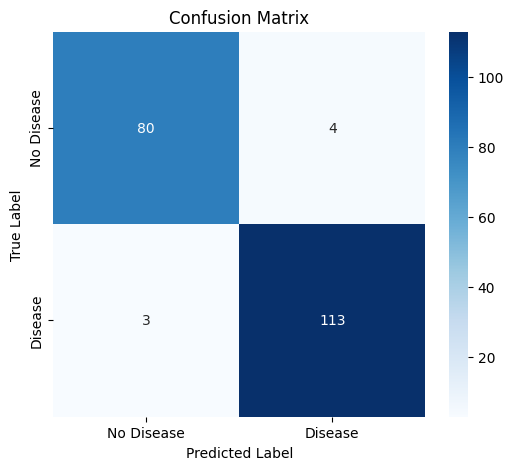

              precision    recall  f1-score   support

  No Disease       0.96      0.95      0.96        84
     Disease       0.97      0.97      0.97       116

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



In [ ]:
y_pred = model1.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

# Define class names (0-no disease,1-disease)
class_names = ['No Disease', 'Disease']

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)


**XGBOOST**

importing the dependencies


In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier

model training

In [ ]:
model2=xgb.XGBClassifier()

In [ ]:
model2.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

model evaluation

accuracy score

In [ ]:
#accuracy on training data
x_train_prediction=model2.predict(x_train)
training_data_accuracy=accuracy_score(x_train_prediction,y_train)


In [ ]:
print('accuracy on training data:',training_data_accuracy)

accuracy on training data: 1.0


In [ ]:
#accuracy on test data
x_test_prediction=model2.predict(x_test)
test_data_accuracy=accuracy_score(x_test_prediction,y_test)


In [ ]:
print('accuracy on test data:',test_data_accuracy)

accuracy on test data: 0.985


building a predictive system

In [ ]:


input_data=(49,1,2,133,142,0,0,202,1,5,1,0)

#change the input data to a numpy array
input_data_as_numpy_array=np.asanyarray(input_data)

#reshape the numpy arrayas we are predicting for only on instance
input_data_reshape=input_data_as_numpy_array.reshape(1,-1)

prediction=model2.predict(input_data_reshape)
print(prediction)


if (prediction [0]==0):
  print('The person does not have a heart disease' )
else:
  print('The person has a heart disease' )


[0]
The person does not have a heart disease


confusion matrix

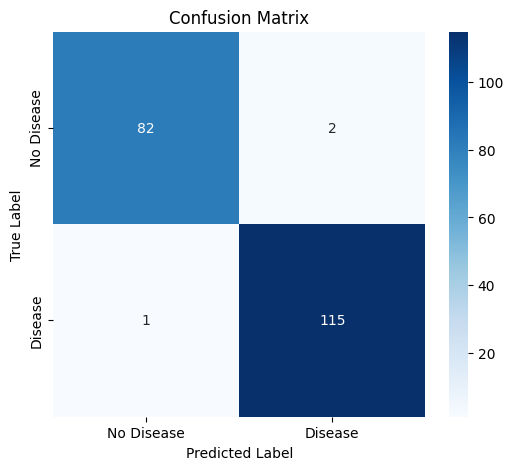

              precision    recall  f1-score   support

  No Disease       0.99      0.98      0.98        84
     Disease       0.98      0.99      0.99       116

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



In [ ]:
y_pred = model2.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

# Define class names (0-no disease,1-disease)
class_names = ['No Disease', 'Disease']

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)



**RANDOM FOREST**

importing the dependencies

In [ ]:
from sklearn.ensemble import RandomForestClassifier


model traning

In [ ]:
model3 = RandomForestClassifier(n_estimators=100, random_state=42)
model3.fit(x_train, y_train)


RandomForestClassifier(random_state=42)

model evaluation

accuracy score


In [ ]:
#accuracy on training data
x_train_prediction=model3.predict(x_train)
training_data_accuracy=accuracy_score(x_train_prediction,y_train)


In [ ]:
print('accuracy on training data:',training_data_accuracy)

accuracy on training data: 1.0


In [ ]:
#accuracy on test data
x_test_prediction=model3.predict(x_test)
test_data_accuracy=accuracy_score(x_test_prediction,y_test)


In [ ]:
print('accuracy on test data:',test_data_accuracy)

accuracy on test data: 0.98


building a predictive system

In [ ]:
input_data=(49,1,2,133,142,0,0,202,1,5,1,0)

#change the input data to a numpy array
input_data_as_numpy_array=np.asanyarray(input_data)

#reshape the numpy arrayas we are predicting for only on instance
input_data_reshape=input_data_as_numpy_array.reshape(1,-1)

prediction=model3.predict(input_data_reshape)
print(prediction)


if (prediction [0]==0):
  print('The person does not have a heart disease' )
else:
  print('The person has a heart disease' )

[0]
The person does not have a heart disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


confusion matrix

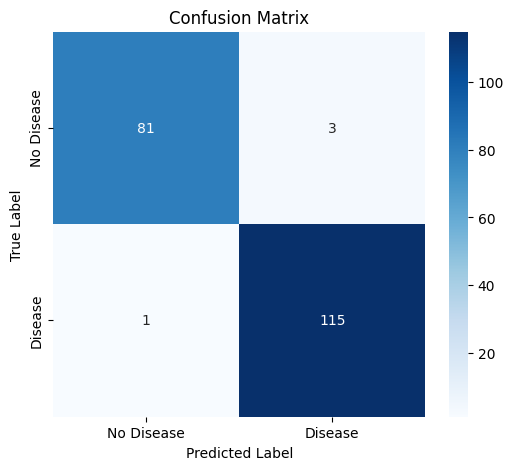

              precision    recall  f1-score   support

  No Disease       0.99      0.96      0.98        84
     Disease       0.97      0.99      0.98       116

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



In [ ]:
y_pred = model3.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

# Define class names (0-no disease,1-disease)
class_names = ['No Disease', 'Disease']

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)


**svm (Support Vector Machine)**

importing the dependencies

model traning

In [ ]:
model4 = SVC(kernel='linear', probability=True)
model4.fit(x_train,y_train)

SVC(kernel='linear', probability=True)

model evaluation

accuracy score

In [ ]:
#accuracy on training data
x_train_prediction=model4.predict(x_train)
training_data_accuracy=accuracy_score(x_train_prediction,y_train)


In [ ]:
print('accuracy on training data:',training_data_accuracy)

accuracy on training data: 0.96625


In [ ]:
#accuracy on test data
x_test_prediction=model4.predict(x_test)
test_data_accuracy=accuracy_score(x_test_prediction,y_test)


In [ ]:
print('accuracy on test data:',test_data_accuracy)

accuracy on test data: 0.985


building a predictive system


In [ ]:
input_data=(49,1,2,133,142,0,0,202,1,5,1,0)

#change the input data to a numpy array
input_data_as_numpy_array=np.asanyarray(input_data)

#reshape the numpy arrayas we are predicting for only on instance
input_data_reshape=input_data_as_numpy_array.reshape(1,-1)

prediction=model4.predict(input_data_reshape)
print(prediction)


if (prediction [0]==0):
  print('The person does not have a heart disease' )
else:
  print('The person has a heart disease' )

[0]
The person does not have a heart disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


confusion matrix





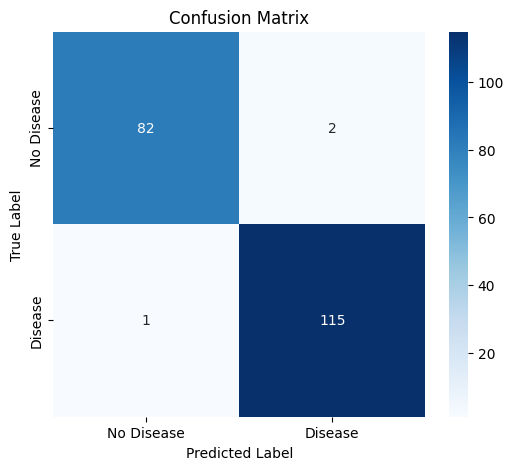

              precision    recall  f1-score   support

  No Disease       0.99      0.98      0.98        84
     Disease       0.98      0.99      0.99       116

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



In [ ]:
y_pred = model4.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

# Define class names (0-no disease,1-disease)
class_names = ['No Disease', 'Disease']

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)


**KNN(K-Nearest Neighbors)**

importing the dependencies

In [ ]:
from sklearn.neighbors import KNeighborsClassifier


model traning

In [ ]:
model5 = KNeighborsClassifier(n_neighbors=4)

model5.fit(x_train, y_train)


KNeighborsClassifier(n_neighbors=4)

model evaluation

accuracy score

In [ ]:
#accuracy on training data
x_train_prediction=model5.predict(x_train)
training_data_accuracy=accuracy_score(x_train_prediction,y_train)


In [ ]:
print('accuracy on training data:',training_data_accuracy)

accuracy on training data: 0.875


In [ ]:
#accuracy on test data
x_test_prediction=model5.predict(x_test)
test_data_accuracy=accuracy_score(x_test_prediction,y_test)


In [ ]:
print('accuracy on test data:',test_data_accuracy)

accuracy on test data: 0.825


building a predictive system

In [ ]:
input_data=(49,1,2,133,142,0,0,202,1,5,1,0)

#change the input data to a numpy array
input_data_as_numpy_array=np.asanyarray(input_data)

#reshape the numpy arrayas we are predicting for only on instance
input_data_reshape=input_data_as_numpy_array.reshape(1,-1)

prediction=model5.predict(input_data_reshape)
print(prediction)


if (prediction [0]==0):
  print('The person does not have a heart disease' )
else:
  print('The person has a heart disease' )

[0]
The person does not have a heart disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


confusion matrix

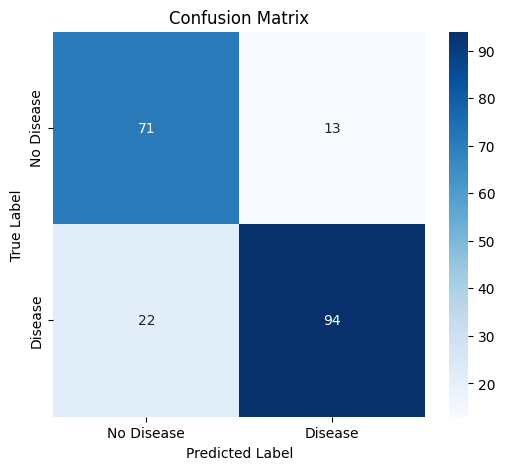

              precision    recall  f1-score   support

  No Disease       0.76      0.85      0.80        84
     Disease       0.88      0.81      0.84       116

    accuracy                           0.82       200
   macro avg       0.82      0.83      0.82       200
weighted avg       0.83      0.82      0.83       200



In [ ]:
y_pred = model5.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

# Define class names (0-no disease,1-disease)
class_names = ['No Disease', 'Disease']

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)


**Linear Discriminant Analysis (LDA)**

importing the dependencies

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

model traning

In [ ]:
model6= LinearDiscriminantAnalysis()
model6.fit(x_train, y_train)

LinearDiscriminantAnalysis()

model evaluation

accuracy score

In [ ]:
#accuracy on training data
x_train_prediction=model6.predict(x_train)
training_data_accuracy=accuracy_score(x_train_prediction,y_train)


In [ ]:
print('accuracy on training data:',training_data_accuracy)

accuracy on training data: 0.9575


In [ ]:
#accuracy on test data
x_test_prediction=model6.predict(x_test)
test_data_accuracy=accuracy_score(x_test_prediction,y_test)


In [ ]:
print('accuracy on test data:',test_data_accuracy)

accuracy on test data: 0.985


building a predictive system


In [ ]:
input_data=(49,1,2,133,142,0,0,202,1,5,1,0)

#change the input data to a numpy array
input_data_as_numpy_array=np.asanyarray(input_data)

#reshape the numpy arrayas we are predicting for only on instance
input_data_reshape=input_data_as_numpy_array.reshape(1,-1)

prediction=model6.predict(input_data_reshape)
print(prediction)


if (prediction [0]==0):
  print('The person does not have a heart disease' )
else:
  print('The person has a heart disease' )

[0]
The person does not have a heart disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


confusion matrix





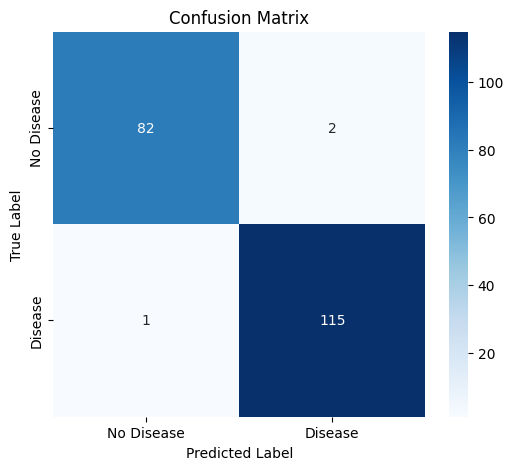

              precision    recall  f1-score   support

  No Disease       0.99      0.98      0.98        84
     Disease       0.98      0.99      0.99       116

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



In [ ]:
y_pred = model6.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

# Define class names (0-no disease,1-disease)
class_names = ['No Disease', 'Disease']

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)


**CatBoost**

importing the dependencies



In [ ]:
%pip install catboost
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.4 MB/s eta 0:00:00


model traning

In [ ]:
model7 = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    eval_metric='Accuracy',
    verbose=0
)

model7.fit(x_train, y_train)


model evaluation

accuracy score

In [ ]:
#accuracy on training data
x_train_prediction=model7.predict(x_train)
training_data_accuracy=accuracy_score(x_train_prediction,y_train)


In [ ]:
print('accuracy on training data:',training_data_accuracy)

accuracy on training data: 1.0


In [ ]:
#accuracy on test data
x_test_prediction=model7.predict(x_test)
test_data_accuracy=accuracy_score(x_test_prediction,y_test)


In [ ]:
print('accuracy on test data:',test_data_accuracy)

accuracy on test data: 0.985


building a predictive system


In [ ]:
input_data=(49,1,2,133,142,0,0,202,1,5,1,0)

#change the input data to a numpy array
input_data_as_numpy_array=np.asanyarray(input_data)

#reshape the numpy arrayas we are predicting for only on instance
input_data_reshape=input_data_as_numpy_array.reshape(1,-1)

prediction=model7.predict(input_data_reshape)
print(prediction)


if (prediction [0]==0):
  print('The person does not have a heart disease' )
else:
  print('The person has a heart disease' )

[0]
The person does not have a heart disease


confusion matrix





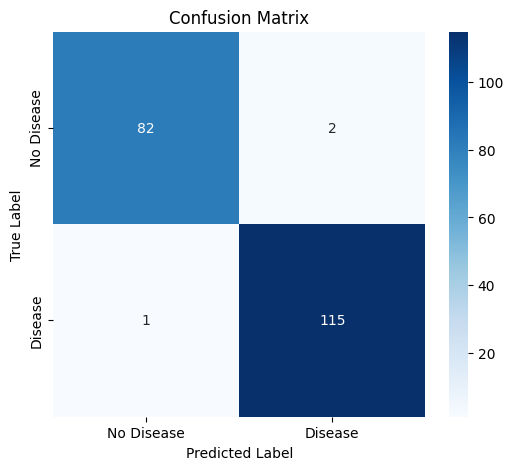

              precision    recall  f1-score   support

  No Disease       0.99      0.98      0.98        84
     Disease       0.98      0.99      0.99       116

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



In [ ]:
y_pred = model7.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

# Define class names (0-no disease,1-disease)
class_names = ['No Disease', 'Disease']

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)


**Gradient Boosting Machines (GBM)**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model traning

In [ ]:
model8= GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model8.fit(x_train, y_train)

GradientBoostingClassifier(random_state=42)

model evaluation

accuracy score

In [ ]:
#accuracy on training data
x_train_prediction=model8.predict(x_train)
training_data_accuracy=accuracy_score(x_train_prediction,y_train)


In [ ]:
print('accuracy on training data:',training_data_accuracy)

accuracy on training data: 1.0


In [ ]:
#accuracy on test data
x_test_prediction=model8.predict(x_test)
test_data_accuracy=accuracy_score(x_test_prediction,y_test)


In [ ]:
print('accuracy on test data:',test_data_accuracy)

accuracy on test data: 0.98


building a predictive system


In [ ]:
input_data=(49,1,2,133,142,0,0,202,1,5,1,0)

#change the input data to a numpy array
input_data_as_numpy_array=np.asanyarray(input_data)

#reshape the numpy arrayas we are predicting for only on instance
input_data_reshape=input_data_as_numpy_array.reshape(1,-1)

prediction=model8.predict(input_data_reshape)
print(prediction)


if (prediction [0]==0):
  print('The person does not have a heart disease' )
else:
  print('The person has a heart disease' )

[0]
The person does not have a heart disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


confusion matrix





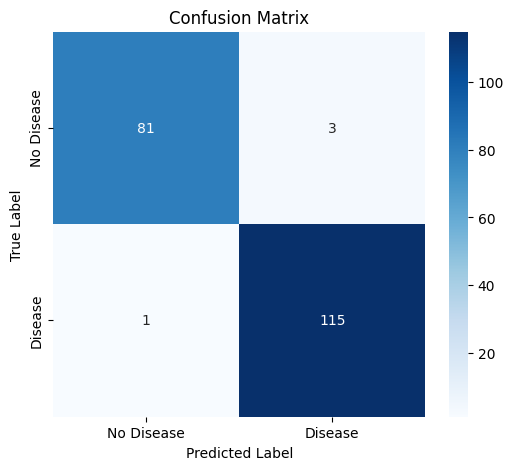

              precision    recall  f1-score   support

  No Disease       0.99      0.96      0.98        84
     Disease       0.97      0.99      0.98       116

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



In [ ]:
y_pred = model8.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

# Define class names (0-no disease,1-disease)
class_names = ['No Disease', 'Disease']

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)


**Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model traning

In [ ]:
model9 = DecisionTreeClassifier(max_depth=4, random_state=42)
model9.fit(x_train, y_train)


DecisionTreeClassifier(max_depth=4, random_state=42)

model evaluation

accuracy score

In [ ]:
#accuracy on training data
x_train_prediction=model9.predict(x_train)
training_data_accuracy=accuracy_score(x_train_prediction,y_train)


In [ ]:
print('accuracy on training data:',training_data_accuracy)

accuracy on training data: 0.97


In [ ]:
#accuracy on test data
x_test_prediction=model9.predict(x_test)
test_data_accuracy=accuracy_score(x_test_prediction,y_test)


In [ ]:
print('accuracy on test data:',test_data_accuracy)

accuracy on test data: 0.95


building a predictive system


In [ ]:
input_data=(49,1,2,133,142,0,0,202,1,5,1,0)

#change the input data to a numpy array
input_data_as_numpy_array=np.asanyarray(input_data)

#reshape the numpy arrayas we are predicting for only on instance
input_data_reshape=input_data_as_numpy_array.reshape(1,-1)

prediction=model9.predict(input_data_reshape)
print(prediction)


if (prediction [0]==0):
  print('The person does not have a heart disease' )
else:
  print('The person has a heart disease' )

[0]
The person does not have a heart disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


confusion matrix





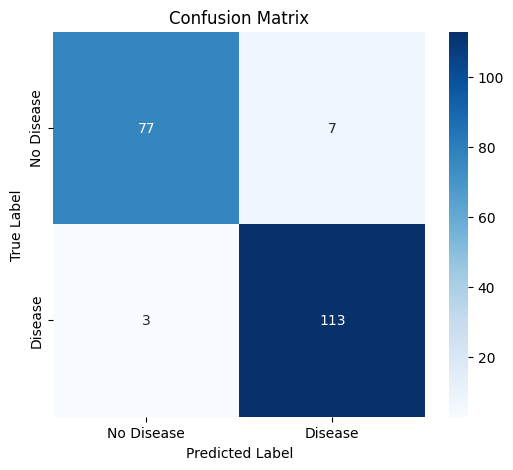

              precision    recall  f1-score   support

  No Disease       0.96      0.92      0.94        84
     Disease       0.94      0.97      0.96       116

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



In [ ]:
y_pred = model9.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

# Define class names (0-no disease,1-disease)
class_names = ['No Disease', 'Disease']

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)


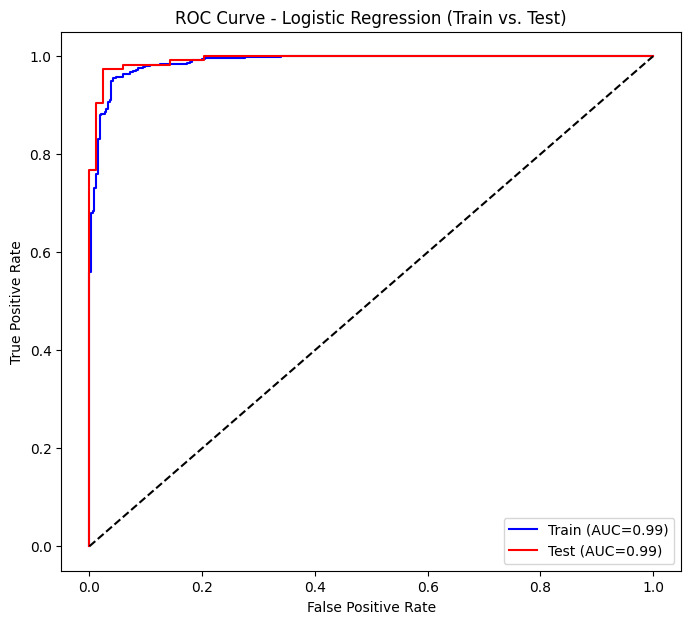

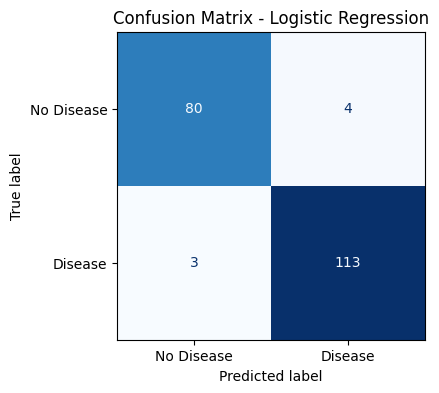

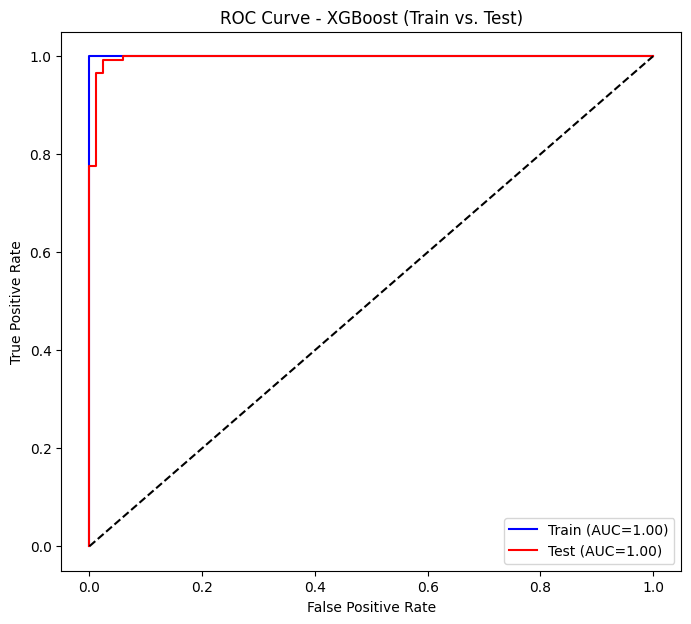

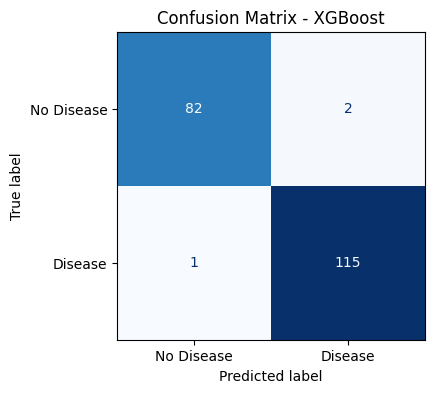

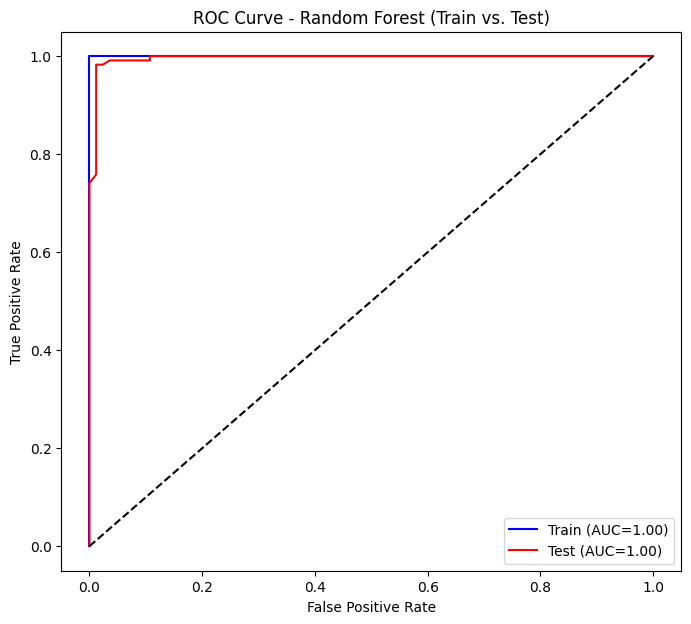

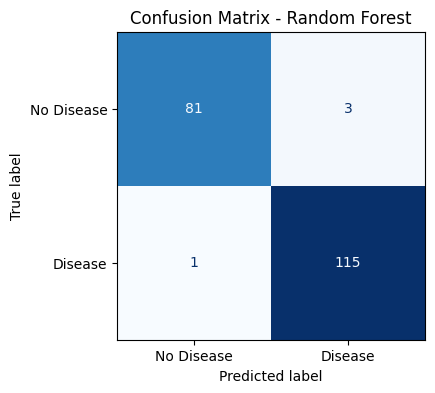

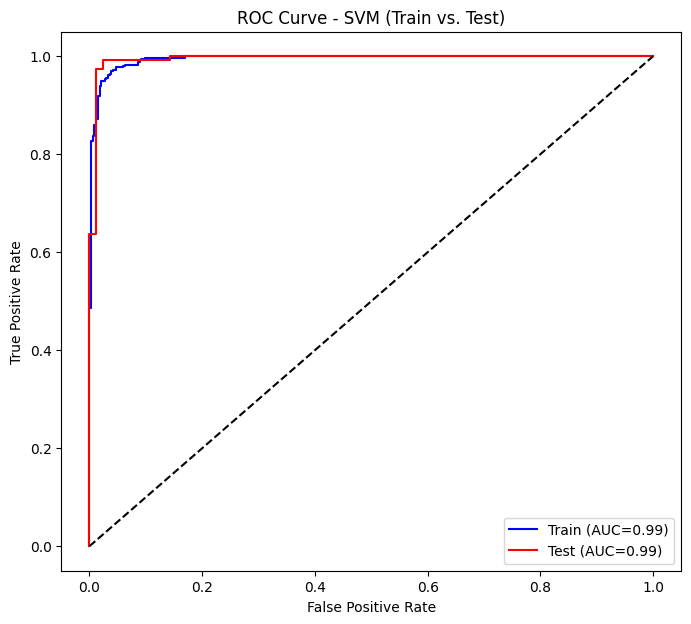

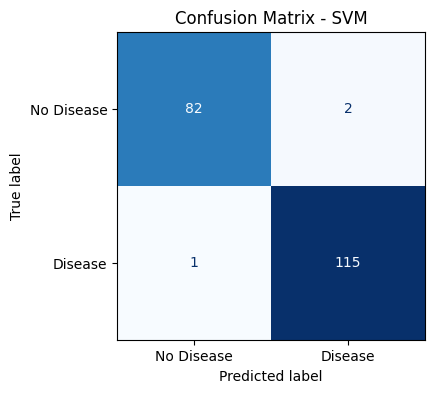

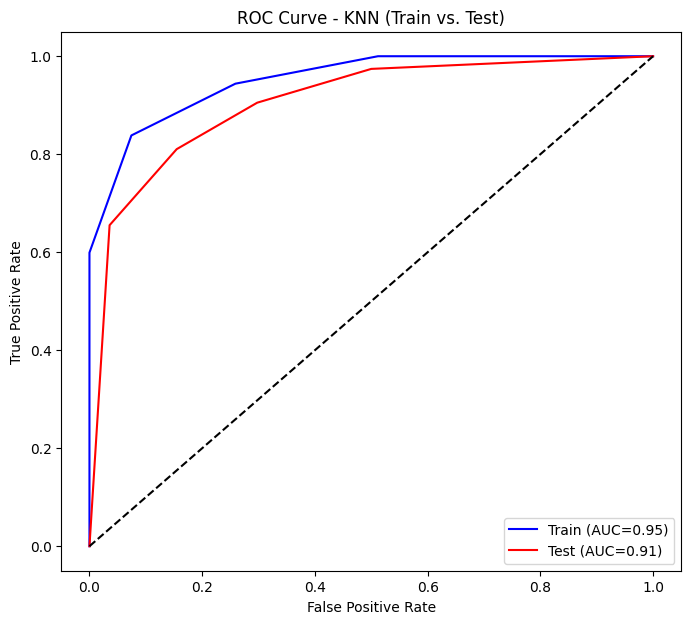

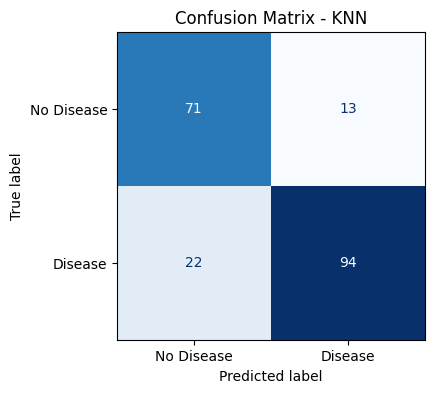

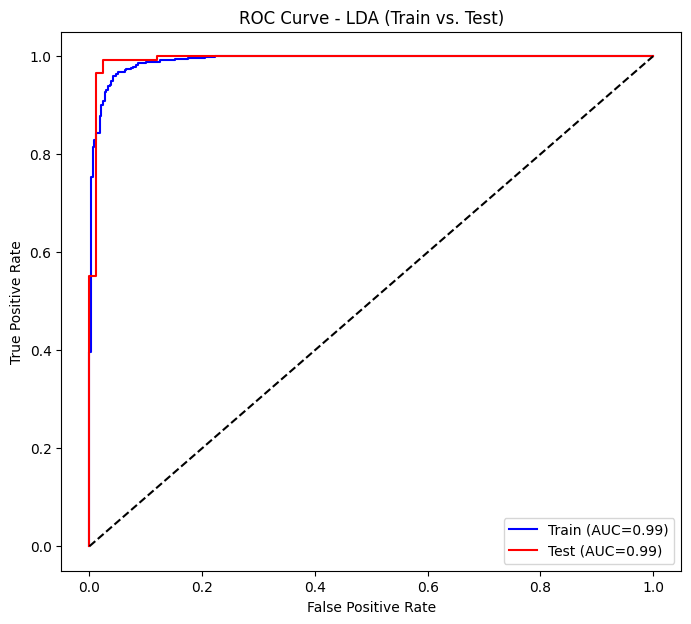

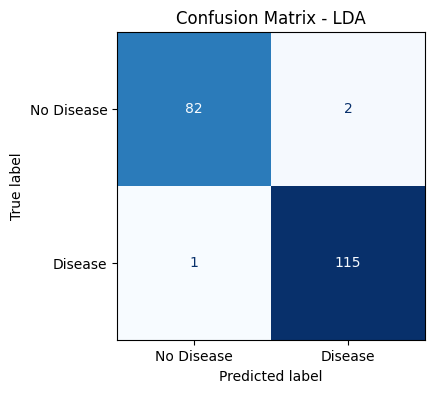

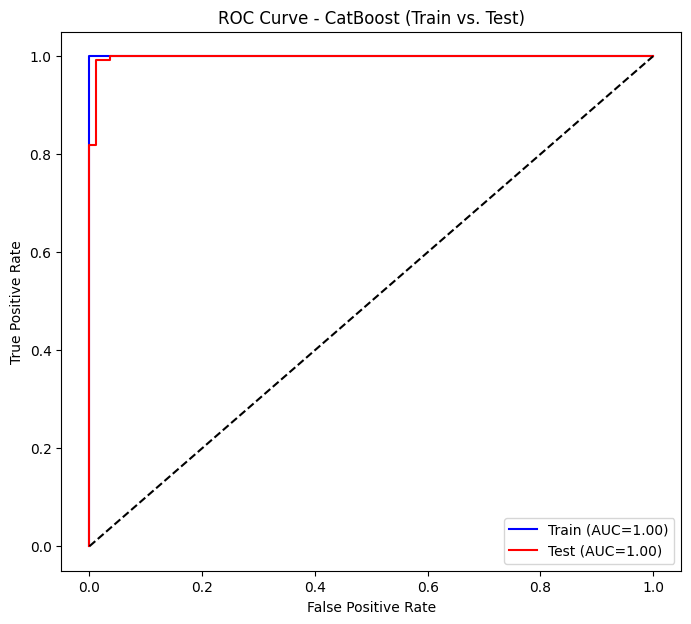

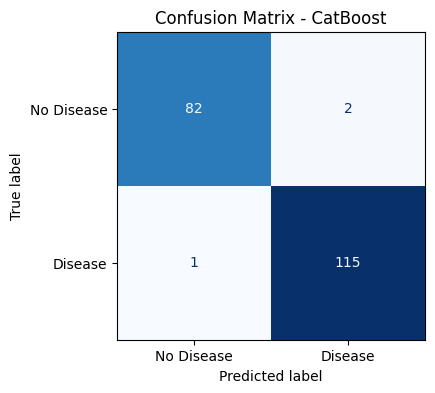

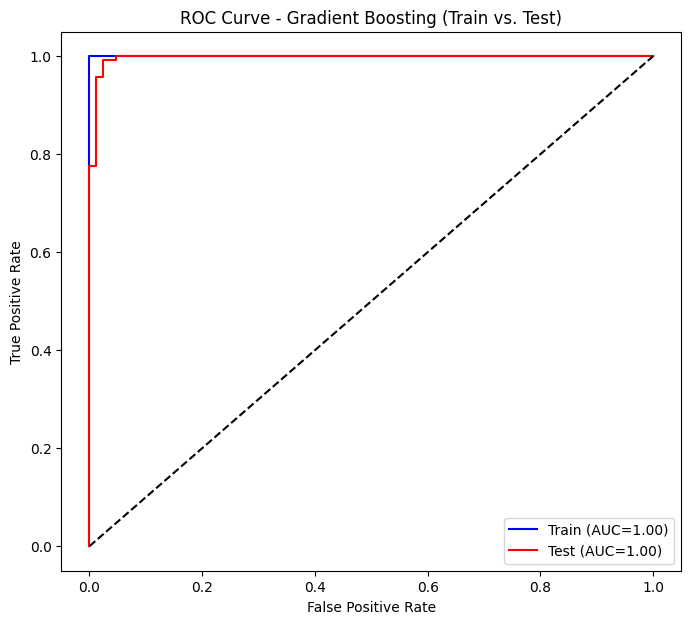

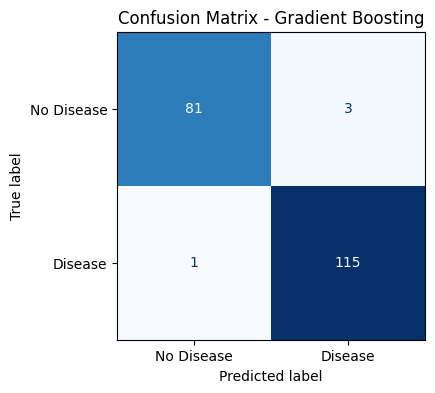

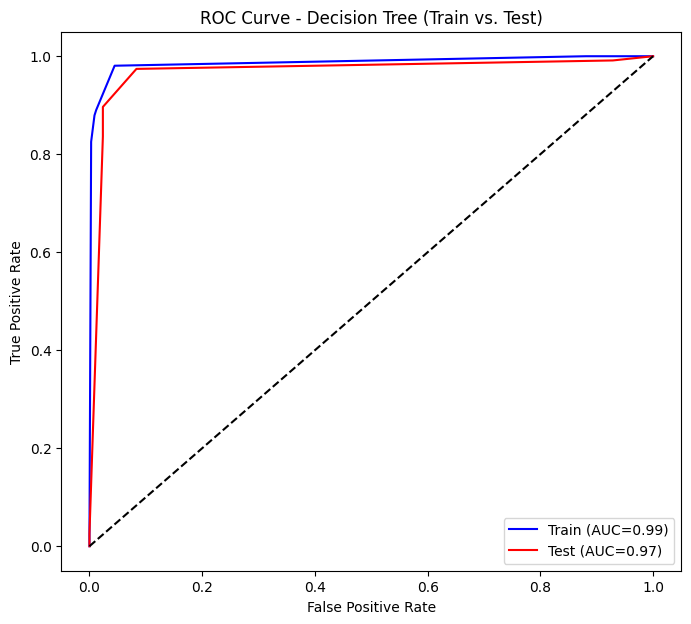

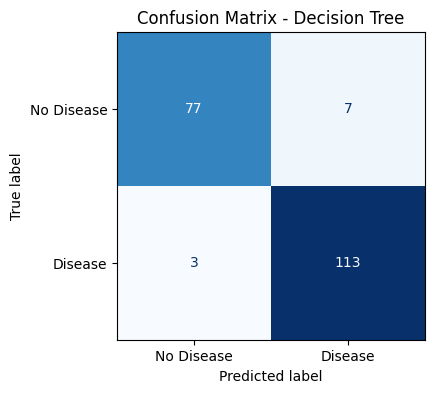

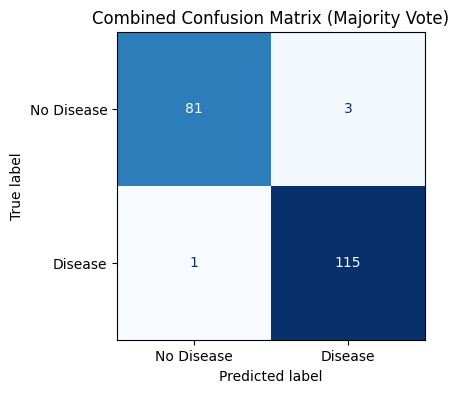


=== Overall Model Evaluation Summary ===

                 Model  Accuracy  Precision    Recall  F1 Score  \
1              XGBoost     0.985   0.982906  0.991379  0.987124   
6             CatBoost     0.985   0.982906  0.991379  0.987124   
3                  SVM     0.985   0.982906  0.991379  0.987124   
5                  LDA     0.985   0.982906  0.991379  0.987124   
7    Gradient Boosting     0.980   0.974576  0.991379  0.982906   
2        Random Forest     0.980   0.974576  0.991379  0.982906   
0  Logistic Regression     0.965   0.965812  0.974138  0.969957   
8        Decision Tree     0.950   0.941667  0.974138  0.957627   
4                  KNN     0.825   0.878505  0.810345  0.843049   

   ROC AUC (Train)  ROC AUC (Test)  
1         1.000000        0.996613  
6         1.000000        0.997640  
3         0.994073        0.994356  
5         0.991322        0.993432  
7         1.000000        0.996613  
2         1.000000        0.996049  
0         0.988474        0

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns # Ensure seaborn is imported for better plotting

# --- Store metrics for table ---
metrics_data = []
y_preds = []

# Define class names for confusion matrix
class_names = ['No Disease', 'Disease']

# Define a dictionary of models to evaluate
models = {
    'Logistic Regression': model1,
    'XGBoost': model2,
    'Random Forest': model3,
    'SVM': model4,
    'KNN': model5,
    'LDA': model6,
    'CatBoost': model7,
    'Gradient Boosting': model8,
    'Decision Tree': model9
}

# ---- ROC curves and Confusion Matrices (individual plots for train and test) ----
for name, model in models.items():
    # Predictions for test data
    y_pred_test = model.predict(x_test)

    # Collect predictions for voting (only using test predictions for voting)
    y_preds.append(y_pred_test.reshape(-1, 1))

    # Metrics for test data
    acc_test = accuracy_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test)
    rec_test = recall_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test)

    roc_auc_train = np.nan
    roc_auc_test = np.nan

    # Plot ROC curve if model has predict_proba
    if hasattr(model, 'predict_proba'):
        # Training data ROC
        y_proba_train = model.predict_proba(x_train)[:, 1]
        fpr_train, tpr_train, _ = roc_curve(y_train, y_proba_train)
        roc_auc_train = roc_auc_score(y_train, y_proba_train)

        # Test data ROC
        y_proba_test = model.predict_proba(x_test)[:, 1]
        fpr_test, tpr_test, _ = roc_curve(y_test, y_proba_test)
        roc_auc_test = roc_auc_score(y_test, y_proba_test)

        plt.figure(figsize=(8, 7))
        plt.plot(fpr_train, tpr_train, label=f'Train (AUC={roc_auc_train:.2f})', color='blue')
        plt.plot(fpr_test, tpr_test, label=f'Test (AUC={roc_auc_test:.2f})', color='red')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {name} (Train vs. Test)')
        plt.legend(loc='lower right')
        plt.show()

    # Plot Confusion Matrix for the current model
    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

    metrics_data.append({
        'Model': name,
        'Accuracy': acc_test,
        'Precision': prec_test,
        'Recall': rec_test,
        'F1 Score': f1_test,
        'ROC AUC (Train)': roc_auc_train,
        'ROC AUC (Test)': roc_auc_test
    })

# --- Combine all predictions for voting ---
y_preds = np.hstack(y_preds)

# Majority vote
from scipy.stats import mode
y_vote, _ = mode(y_preds, axis=1)
y_vote = y_vote.ravel()

cm_vote = confusion_matrix(y_test, y_vote)
disp_vote = ConfusionMatrixDisplay(confusion_matrix=cm_vote, display_labels=class_names)
fig_vote, ax_vote = plt.subplots(figsize=(4, 4))
disp_vote.plot(cmap='Blues', ax=ax_vote, colorbar=False)
plt.title('Combined Confusion Matrix (Majority Vote)')
plt.show()

# --- Metrics table ---
metrics_df = pd.DataFrame(metrics_data).sort_values(by="Accuracy", ascending=False)
print("\n=== Overall Model Evaluation Summary ===\n")
print(metrics_df)

In [ ]:
"""
CONVERT GOOGLE COLAB TO WORD - NO DRIVE NEEDED
Run this cell in your Colab notebook!
"""

# Step 1: Install requirements
print("Installing requirements...")
!apt-get install -y pandoc > /dev/null 2>&1
!pip install -q nbconvert

# Step 2: Instructions
print("\n" + "="*60)
print("STEP-BY-STEP INSTRUCTIONS:")
print("="*60)
print("\n1. Click 'File' → 'Download' → 'Download .ipynb'")
print("   (This downloads your notebook to your computer)")
print("\n2. After downloading, you'll upload it back here")
print("\n3. We'll convert it to Word and download it")
print("\n" + "="*60)

input("\nPress ENTER after you've downloaded the .ipynb file...")

# Step 3: Upload the notebook
print("\n📤 Now upload the .ipynb file you just downloaded:")
from google.colab import files
uploaded = files.upload()

# Step 4: Get the uploaded filename
notebook_name = list(uploaded.keys())[0]
print(f"\n✓ Uploaded: {notebook_name}")

# Step 5: Convert to Word
print("\nConverting to Word...")
!jupyter nbconvert --to docx "{notebook_name}"

# Step 6: Download Word file
docx_name = notebook_name.replace('.ipynb', '.docx')
print(f"\n📥 Downloading: {docx_name}")
files.download(docx_name)

print("\n✅ SUCCESS! Your Word document has been downloaded!")
print(f"File: {docx_name}")

Installing requirements...

STEP-BY-STEP INSTRUCTIONS:

1. Click 'File' → 'Download' → 'Download .ipynb'
   (This downloads your notebook to your computer)

2. After downloading, you'll upload it back here

3. We'll convert it to Word and download it

